# **Exploratory Data Analysis and Linguistic Analysis**

In [ ]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
from collections import Counter
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 50)

## **1. Exploratory Data Analysis**

### **1.1 Data Loading**

Before any exploratory analysis, we load the cleaned dataset produced by
notebook `01_data_preparation`. That notebook merged the raw tweet files,
cleaned the text (fixing encoding issues, converting emojis to text, removing
URLs and mentions), and assigned each tweet one of four sentiment labels.

Here we simply load that output and prepare it for analysis. All subsequent
exploration in this notebook is based on this single, reproducible source file:
`data/processed/artemis_master_dataset.csv`.

The notebook runs both on Google Colab (with Drive
mounted) and on a local machine. The cell below detects the environment and
sets the project root accordingly, so the same notebook works in both cases
without editing paths.

In [ ]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ARTEMIS_Sentiment_Analysis'
else:
    # On a laptop, the notebook lives in <repo>/notebooks/, so go up one level
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
DATASET_PATH = os.path.join(PROCESSED_DIR, 'artemis_master_dataset.csv')

print("IN_COLAB:", IN_COLAB)
print("DATASET_PATH:", DATASET_PATH)

Mounted at /content/drive
IN_COLAB: True
DATASET_PATH: /content/drive/MyDrive/ARTEMIS_Sentiment_Analysis/data/processed/artemis_master_dataset.csv


In [ ]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Master dataset not found at:\n  {DATASET_PATH}\n\n"
        "Did you run notebook 01 first? It produces "
        "data/processed/artemis_master_dataset.csv."
    )

df = pd.read_csv(DATASET_PATH, encoding='utf-8')

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

Loaded 6624 rows, 4 columns
Columns: ['text', 'Sentiment_label', 'source', 'cleaned_text']


The dataset stores two text columns: the
original raw `text` and the `cleaned_text` produced in notebook 01. For the
analysis we keep only the cleaned version, so we drop the raw column and rename
`cleaned_text` to `text`. We also drop any rows without a sentiment label.

Finally, we confirm the four sentiment classes
present in the dataset. These four labels are the target of all classification
models in this project.

In [ ]:
df = df.drop(columns=['text'])
df = df.rename(columns={'cleaned_text': 'text'})
df = df.dropna(subset=['Sentiment_label']).reset_index(drop=True)

print(f"Dataset ready for EDA: {df.shape[0]} rows.")
display(df[['text', 'Sentiment_label']].head())

Dataset ready for EDA: 6623 rows.


,text,Sentiment_label
0,NASA No just get back safe double exclamation ...,Enthusiastic
1,Rainmaker1973 Artemis 2 engine power from drop...,Neutral
2,If only Carl Sagan was alive for this moment A...,Enthusiastic
3,Aretmis' is laughable CGI. The Clangers were m...,Conspiratorial
4,Isn't it very fascinating that this is the fir...,Enthusiastic


In [ ]:
unique_categories = df['Sentiment_label'].unique().tolist()
print(f"Categories: {unique_categories}")

Categories: ['Enthusiastic', 'Neutral', 'Conspiratorial', 'Critical/Skeptical']


The dataset uses four sentiment labels: **E** (Enthusiastic), **N** (Neutral),  **C** (Conspiratorial), **S** (Critical/Skeptical). These categories were assigned during the annotation phase of the original dataset construction.

### **1.2 Basic Statistics**

In [ ]:
df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

display(df[['Sentiment_label', 'char_count', 'word_count']].head(10))

,Sentiment_label,char_count,word_count
0,Enthusiastic,132,22
1,Neutral,56,8
2,Enthusiastic,54,10
3,Conspiratorial,206,35
4,Enthusiastic,135,23
5,Critical/Skeptical,48,9
6,Enthusiastic,117,22
7,Neutral,105,18
8,Neutral,249,42
9,Conspiratorial,95,17


In [ ]:
display(df[['char_count', 'word_count']].describe())

,char_count,word_count
count,6623.000000,6623.000000
mean,151.306961,25.844481
std,102.604670,17.618365
min,12.000000,2.000000
25%,78.000000,13.000000
50%,130.000000,22.000000
75%,213.000000,36.000000
max,1642.000000,284.000000


Both `char_count` and `word_count` are strongly right-skewed: the mean (151
characters) sits well above the median (130), and the maximum (1,642 characters)
is more than seven times the 75th percentile (213). In other words, a small
number of very long tweets pulls the average upward, while the bulk of the data
is short, half of all tweets are under 130 characters. The minimum of 2 words
confirms the presence of very brief entries typical of social media.

This distribution directly informs a later modeling choice: because the vast
majority of tweets are short but a few are extreme outliers, a maximum sequence
length set near the upper percentiles (rather than the maximum) will cover most
of the data while keeping inputs compact.

### **1.3 Labels Distribution**

We examine how the four sentiment classes are distributed across the dataset.
This is one of the most important properties to establish early, because class
balance directly shapes the modeling strategy and the choice of evaluation
metric.

#### **1.3.1 Phase-by-Phase Labels Distribution**

Before analyzing the full dataset, it is interesting to investigate how public perception shifted across the three core, high-stakes phases of the Artemis II mission: **Departure**, **Flyby**, and **Return**. Examining these milestones individually allows us to uncover the immediate emotional responses to specific mission events and highlights the structural class imbalances that surfaced.

Following this phase-specific exploratory analysis, we will display the label distribution of the final compiled dataset.



For this phase-level analysis, we rely on the `source` column added during the
data preparation in `01_data_preparation`. When the five raw files were merged, each row was
tagged with its origin (`departure`, `flyby`, `return`, `conspiracyhunt`,
`photoday`), and this column was preserved through the entire cleaning pipeline
(sentiment mapping, text cleaning, and deduplication) into the final master dataset.

This means we can build the phase distributions simply by slicing the already-cleaned
dataset (`df[df['source'] == phase]`), without re-loading or re-processing the raw
files. As a result, the per-phase counts are fully consistent with the rest of the
analysis: they come from the same deduplicated and standardized data used throughout
the project. Note that only the three mission phases (departure, flyby, return) are
shown here; the two thematic collections (`conspiracyhunt`, `photoday`) are part of
the full dataset but do not correspond to a mission phase.

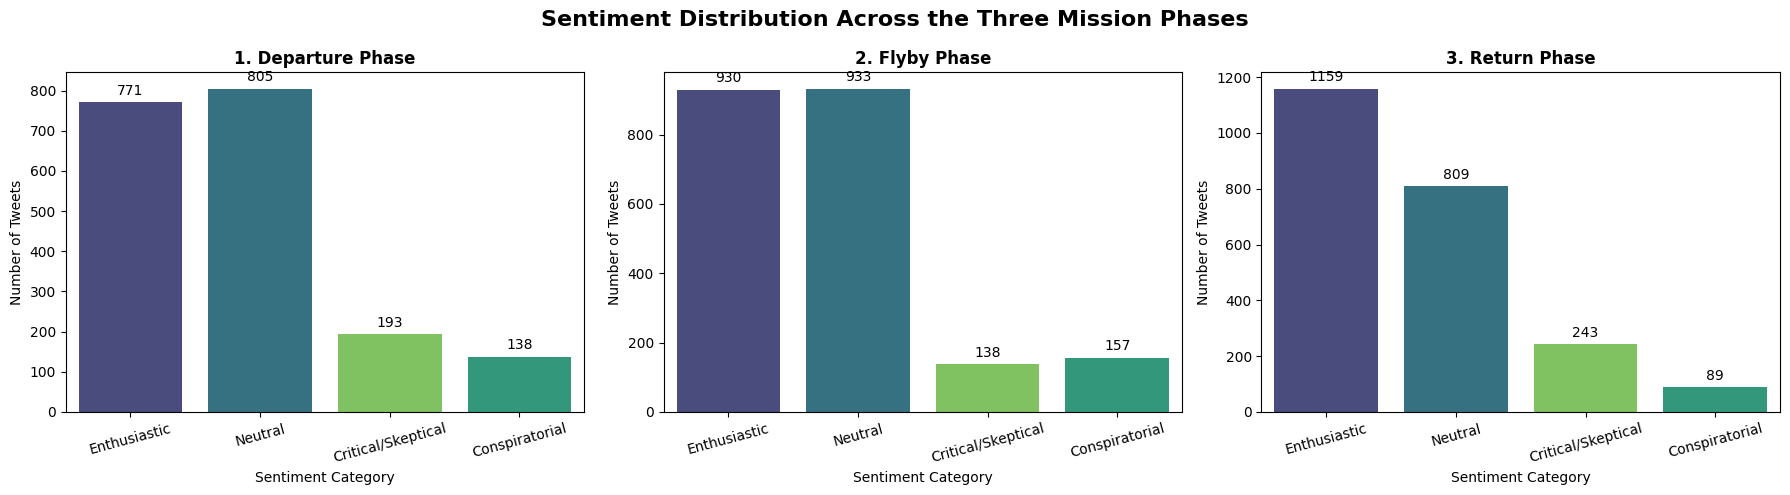

In [ ]:
phase_order = ['departure', 'flyby', 'return']
phase_titles = {'departure': '1. Departure Phase',
                'flyby': '2. Flyby Phase',
                'return': '3. Return Phase'}
label_order = ['Enthusiastic', 'Neutral', 'Critical/Skeptical', 'Conspiratorial']

viridis_colors = sns.color_palette('viridis', 4)
custom_palette = {
    'Enthusiastic': viridis_colors[0],
    'Neutral': viridis_colors[1],
    'Critical/Skeptical': viridis_colors[3],
    'Conspiratorial': viridis_colors[2]
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('Sentiment Distribution Across the Three Mission Phases',
             fontsize=16, fontweight='bold')

for ax, phase in zip(axes, phase_order):
    phase_df = df[df['source'] == phase]      # ← slice the clean df, no re-loading

    sns.countplot(
        data=phase_df, x='Sentiment_label',
        order=label_order, hue_order=label_order,
        palette=custom_palette, hue='Sentiment_label',
        legend=False, ax=ax
    )
    ax.set_title(phase_titles[phase], fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment Category', fontsize=10)
    ax.set_ylabel('Number of Tweets', fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

Looking at the sentiment distribution across the three key phases of the Artemis II
mission reveals clear shifts in public discourse, each tied to the specific events
of that phase.

The most interesting pattern concerns the *Conspiratorial* class. Its share was
highest during the **Flyby Phase** (7.3%) and **Departure** (7.2%), but dropped
sharply during the **Return Phase** (3.9%). A plausible explanation is that the
flyby, the part of the mission farthest from Earth, where the public cannot
independently verify what is happening, offered the most fertile ground for hoax
theories and science denial. Once the crew returned and splashdown was broadcast,
this kind of narrative declined.

The *Critical/Skeptical* class shows the opposite trend: it peaked during
**Departure** (10.1%) and **Return** (10.5%), but was lower during the flyby (6.3%).
Based on our observations during manual data collection, these critiques were mostly
operational and technical rather than conspiratorial. At departure, users often
complained about the quality or availability of the broadcast footage; at return,
many scrutinised the logistics and safety procedures of the splashdown recovery.
In other words, skepticism here reflects practical concerns about how the mission
was carried out, not denial that it happened.

Finally, the **Return Phase** is marked by a strong rise in *Enthusiastic* sentiment,
which exceeds 50% of all tweets in that phase. This reflects the public's relief and
excitement at the successful conclusion of the mission.

It is also worth noting that *Neutral* remains a large share across all three phases,
consistent with the substantial amount of informational and news-style reporting in
the dataset. Overall, the phase breakdown shows that sentiment was not static: the
discourse moved from a mix of anticipation and technical scrutiny at departure,
through a peak of conspiratorial narratives during the flyby, to relief and
celebration at return.

#### **1.3.2 Full Dataset Distribution**

,proportion
Sentiment_label,
Enthusiastic,43.18%
Neutral,38.46%
Critical/Skeptical,9.81%
Conspiratorial,8.55%


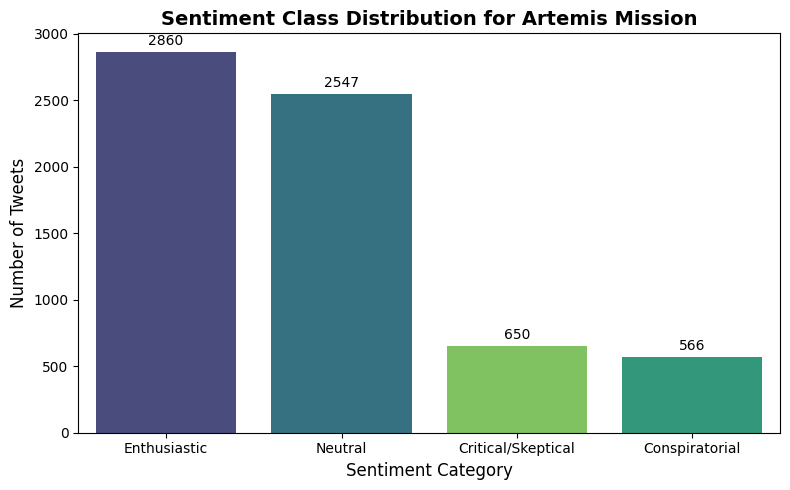

In [ ]:
percentages = (df['Sentiment_label'].value_counts(normalize=True) * 100).apply(lambda x: f"{x:.2f}%")
display(percentages)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Sentiment_label',
    order=df['Sentiment_label'].value_counts().index,
    palette='viridis',
    hue='Sentiment_label',
    legend=False
)
plt.title('Sentiment Class Distribution for Artemis Mission', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

The dataset is strongly **imbalanced**. The two majority classes, Enthusiastic
(43.2%) and Neutral (38.5%), together account for over 80% of the tweets, while
the two minority classes, Critical/Skeptical (9.8%) and Conspiratorial (8.6%)
are far smaller, with roughly 650 and 566 tweets respectively.

This imbalance has two direct consequences for the rest of the project:

- **Evaluation metric.** Overall accuracy would be misleading: a model could
  reach $\approx 82$% accuracy by predicting only the two majority classes and ignoring
  the minorities entirely. We therefore adopt **macro-averaged F1** as the
  headline metric, since it weights all four classes equally and rewards correct
  classification of the rare classes.
- **Training strategy.** To prevent models from neglecting the minority classes,
  we apply **class weighting** during training, so that errors on the
  underrepresented classes are penalized more heavily.

### **1.4 Text Length Distribution**

Next we analyze tweet length, measured both in characters and in words. Length
distribution matters because it informs how text is vectorized, in particular,
the maximum sequence length used when tokenizing for the models.

The histograms below show the distribution of
character and word counts across all tweets, with the median marked.

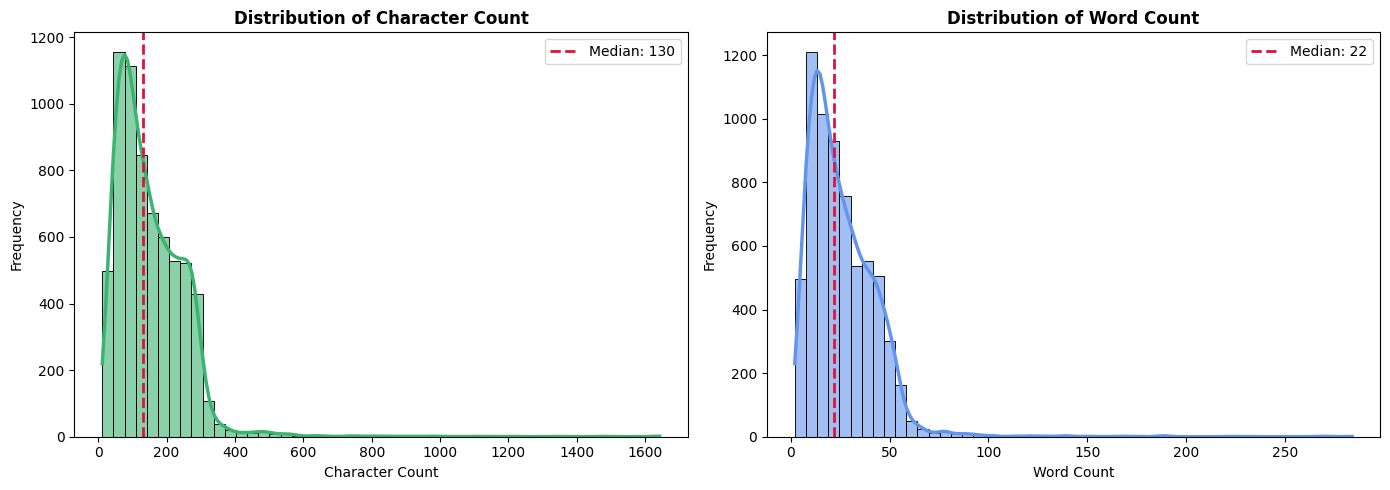

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['char_count'], bins=50, kde=True, edgecolor='black', alpha=0.6,
             color='mediumseagreen', line_kws={'color': 'darkgreen', 'linewidth': 2.5}, ax=axes[0])
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Character Count', fontweight='bold')
char_median = df['char_count'].median()
axes[0].axvline(char_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {char_median:.0f}')
axes[0].legend()

sns.histplot(df['word_count'], bins=50, kde=True, edgecolor='black', alpha=0.6,
             color='cornflowerblue', line_kws={'color': 'midnightblue', 'linewidth': 2.5}, ax=axes[1])
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count', fontweight='bold')
word_median = df['word_count'].median()
axes[1].axvline(word_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {word_median:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

The overall distributions confirm the right-skew seen in the summary statistics:
most tweets are short (median 130 characters / 22 words), with a thin tail of
much longer ones. We now break this down **by sentiment class** to see whether
length differs across categories.

,count,mean,std,min,25%,50%,75%,max
Sentiment_label,,,,,,,,
Conspiratorial,566.0,179.12,141.02,17.0,91.0,155.5,237.00,1642.0
Critical/Skeptical,650.0,183.53,120.36,21.0,107.0,164.5,244.75,1636.0
Enthusiastic,2860.0,143.10,91.45,12.0,73.0,122.5,201.00,1342.0
Neutral,2547.0,146.12,96.68,14.0,73.0,124.0,210.00,1208.0
,count,mean,std,min,25%,50%,75%,max
Sentiment_label,,,,,,,,
Conspiratorial,566.0,31.73,25.19,4.0,16.00,28.0,42.0,284.0
Critical/Skeptical,650.0,32.31,20.61,3.0,19.25,29.0,43.0,270.0
Enthusiastic,2860.0,24.56,15.56,2.0,13.00,21.0,34.0,223.0


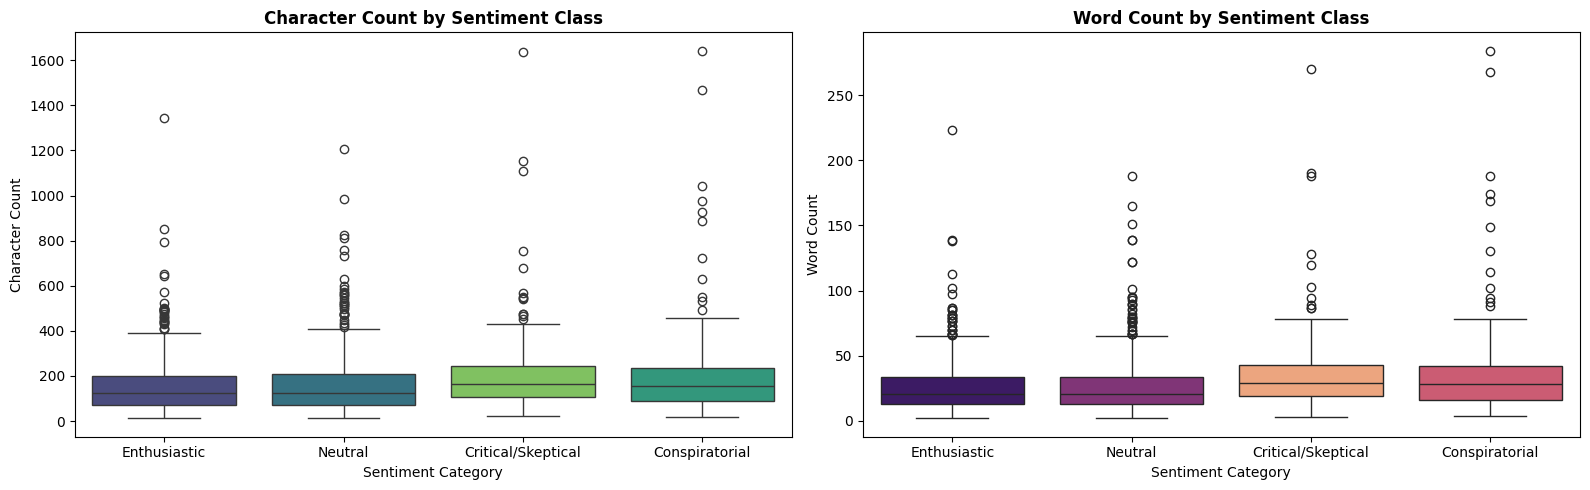

In [ ]:
stats_char = df.groupby('Sentiment_label')['char_count'].describe().round(2)
stats_word = df.groupby('Sentiment_label')['word_count'].describe().round(2)

html_layout = f"""
<div style="display: flex; justify-content: space-around; margin-bottom: 20px;">
    <div style="width: 48%;">
        <h3 style="text-align:center;">Descriptive Stats: Character Count</h3>
        {stats_char.to_html()}
    </div>
    <div style="width: 48%;">
        <h3 style="text-align:center;">Descriptive Stats: Word Count</h3>
        {stats_word.to_html()}
    </div>
</div>
"""
display(HTML(html_layout))

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='Sentiment_label', y='char_count', palette='viridis', ax=axes[0],
            order=df['Sentiment_label'].value_counts().index, hue='Sentiment_label')
axes[0].set_title('Character Count by Sentiment Class', fontweight='bold')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Character Count')

sns.boxplot(data=df, x='Sentiment_label', y='word_count', palette='magma', ax=axes[1],
            order=df['Sentiment_label'].value_counts().index, hue='Sentiment_label')
axes[1].set_title('Word Count by Sentiment Class', fontweight='bold')
axes[1].set_xlabel('Sentiment Category')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

Breaking length down by class reveals a modest but consistent pattern: the two
**minority classes tend to be longer** than the majority classes. Critical/Skeptical
(median 164 characters / 29 words) and Conspiratorial (median 155 characters / 28
words) are noticeably longer than Enthusiastic (122 / 21) and Neutral (124 / 21).

This is intuitive: expressing skepticism or a conspiratorial argument typically
requires more elaboration, reasoning, references, rhetorical questions, whereas
enthusiasm or neutral statements are often expressed briefly. All four classes,
however, share the same heavy right-tail of outliers (up to $\approx 1,600$ characters).

For modeling, the key implication is that the bulk of tweets are short: even for
the longer minority classes, the 75th percentile stays under $\approx 245$ characters
($\approx 43$ words). A maximum sequence length set around the upper percentiles therefore
covers the vast majority of every class while truncating only the rare extreme
outliers.

### **1.5 Token Analysis**

> NLP Setup: spaCy Initialization

To explore the vocabulary of the corpus, we build a lightweight preprocessing
pipeline with **spaCy**. Note this analysis is exploratory, it characterizes
the dataset's vocabulary; it is separate from the text preparation used to train
the models.

The pipeline applies:
- **Tokenization**: splitting each tweet into individual tokens.
- **Lowercasing**: so words are counted identically regardless of case.
- **Noise filtering**: removing punctuation, whitespace, and stopwords.

This lets us measure the vocabulary size and identify the most distinctive terms.

In [ ]:
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("spaCy environment successfully initialized!")

spaCy environment successfully initialized!


In [ ]:
docs = list(nlp.pipe(df['text'].astype(str), batch_size=100))

all_tokens = []
all_tokens_no_stop = []
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            word = token.text.lower()
            all_tokens.append(word)
            if not token.is_stop:
                all_tokens_no_stop.append(word)

print("--- Token Analysis Summary ---")
print(f"Total tokens: {len(all_tokens)}")
print(f"Tokens without stopwords: {len(all_tokens_no_stop)}")
print(f"Unique tokens: {len(set(all_tokens))}")
print(f"Unique tokens (no stopwords): {len(set(all_tokens_no_stop))}")

--- Token Analysis Summary ---
Total tokens: 174920
Tokens without stopwords: 97656
Unique tokens: 12256
Unique tokens (no stopwords): 11965


The token counts give a sense of raw vocabulary size, but raw frequency treats
all words equally. To find the *distinctive* terms, those that characterize the
corpus rather than just appearing often, we turn to TF-IDF.

> NLP Visualization using **TF-IDF**

**TF-IDF** (Term Frequency-Inverse Document Frequency) is a fundamental tool in text analysis.

Instead of just counting occurrences, TF-IDF measures a word's true relevance by weighing its local presence (within a single document) against its global rarity (across the entire dataset). It actively downweights generic, everyday words that appear everywhere, while boosting the score of unique terms that give a specific document its identity. Thanks to this mathematical filtering, the words that achieve the highest TF-IDF scores are genuinely the most defining and meaningful concepts of the text.

The algorithm is built on two main components:

* **Term Frequency (TF):** This looks at a single document at a time. It measures how frequently a specific word appears within that exact text.
* **Inverse Document Frequency (IDF):** This looks at the big picture. It analyzes the entire dataset to see how many total documents contain that specific word, penalizing terms that are too common.

The mathematical formulation is as follows:

$$tf(t, d) = f_{t,d}$$

$$idf(t) = \ln\left(\frac{1 + N}{1 + df(t)}\right) + 1$$

$$tfidf(t, d) = tf(t, d) \times idf(t)$$

Where:
* $f_{t,d}$ is the number of times the term $t$ appears in document $d$.
* $N$ is the total number of documents in the dataset.
* $df(t)$ is the number of documents that contain the target term $t$.

In [ ]:
all_stop_words = list(ENGLISH_STOP_WORDS)

tfidf_vectorizer = TfidfVectorizer(max_features=3000, stop_words=all_stop_words, ngram_range=(1, 1))
X_tfidf = tfidf_vectorizer.fit_transform(df['text'].fillna(''))
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"Vocabulary extracted: {len(feature_names)} terms.")

word_scores = X_tfidf.sum(axis=0).A1
df_words = pd.DataFrame({'word': feature_names, 'score': word_scores})
top_20_words = df_words.sort_values(by='score', ascending=False).head(20)
top_20_words = top_20_words.sort_values(by='score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_20_words['word'], x=top_20_words['score'], orientation='h',
    marker=dict(color=top_20_words['score'], colorscale='Plasma', line=dict(color='white', width=1)),
    name='TF-IDF Score'
))
fig.update_layout(
    title='<b>Top 20 Most Important Terms in Artemis Dataset (Global TF-IDF)</b>',
    xaxis_title="Cumulative TF-IDF Score", yaxis_title="Terms",
    template='plotly_white', height=700, margin=dict(l=150),
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(0,0,0,0.1)')
fig.show()

TF-IDF Matrix Shape: (6623, 3000)
Vocabulary extracted: 3000 terms.


The TF-IDF ranking confirms a tightly domain-focused corpus: the top four terms
(*artemis*, *artemisii*, *moon*, *nasa*) are high-frequency anchors shared across
nearly all documents, hence their high cumulative scores despite IDF down-weighting
ubiquitous terms.

Two observations stand out:

- **Tokenization artifacts.** *artemisii* and *artemis2* appear as separate terms
  for what is essentially the same concept (the Artemis II mission). Likewise,
  *face* ranks highly,  a trace of the emoji-to-text conversion applied in `01_data_preparation` notebook
  (e.g. "crying face", "rolling on the floor laughing"), where the word "face"
  recurs. These reflect preprocessing choices rather than distinct content.
- **Affective vocabulary.** Terms like *welcome* and *home* (likely from
  splashdown / crew-return coverage) suggest that sentiment-bearing words, though
  less frequent than the domain anchors, are present and may help discriminate
  between classes.

## **2. Linguistic Analysis**

### **2.1 Lemma Analysis**

In the previous section we analyzed *raw tokens*, words exactly as they appear
in the text. Here we go one step further with **lemmatization**: reducing each
word to its base dictionary form (its *lemma*). For example, "running", "ran",
and "runs" all map to "run"; "missions" maps to "mission".

Lemmatization matters for two reasons:
- It **shrinks the vocabulary** by merging inflected forms of the same word, so
  related variants are treated as one concept.
- It produces a cleaner TF-IDF ranking, where a word's importance is no longer
  split across its grammatical variants.

We also apply a small **domain-specific unification step**: the variants
*artemis2* and *artemisii* are mapped to a single canonical form *artemis*,
fixing the tokenization artifact identified in section 1.5. The token "amp" (an
HTML residue from `&amp;`) is removed.

We first quantify how much
lemmatization compresses the vocabulary, by comparing the number of unique
tokens against the number of unique lemmas.

In [ ]:
# Domain-specific lemma unification (defined once, reused by later cells)
custom_mapping = {
    'artemis2': 'artemis',
    'artemisii': 'artemis',
    'amp': ''
}

all_lemmas = []
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space and not token.is_stop:
            lemma = token.lemma_.lower().strip()
            if lemma in custom_mapping:
                lemma = custom_mapping[lemma]
            if lemma != '-pron-' and len(lemma) > 1:
                all_lemmas.append(lemma)

unique_tokens = len(set(all_tokens_no_stop))
unique_lemmas = len(set(all_lemmas))
reduction_percentage = (1 - unique_lemmas / unique_tokens) * 100

print("--- Lemmatization Effect ---")
print(f"Unique tokens (no stopwords): {unique_tokens}")
print(f"Unique lemmas (no stopwords): {unique_lemmas}")
print(f"Vocabulary reduction: {reduction_percentage:.1f}%")

--- Lemmatization Effect ---
Unique tokens (no stopwords): 11965
Unique lemmas (no stopwords): 10205
Vocabulary reduction: 14.7%


Lemmatization reduces the unique vocabulary from 11,965 tokens to 10,205 lemmas, a **14.7% reduction**. This is a moderate compression: many inflected forms are
merged, but the corpus retains a large, varied vocabulary, consistent with
free-form social-media text.

To run TF-IDF on lemmas, we
reconstruct each tweet as a string of its lemmas (via `build_lemma_docs`). We
create two versions:
- `lemma_docs`, that is the full lemmatized corpus.
- `lemma_docs_no_artemis`, that is the same, but with *artemis* removed.

The second version is prepared for the later **bigram analysis**: because
*artemis* is by far the most frequent term, it would otherwise dominate every
two-word combination ("artemis mission", "artemis launch", ...) and crowd out
more informative pairs. Removing it lets other bigrams surface.

In [ ]:
def build_lemma_docs(docs, mapping, extra_stopwords=None):
    extra_stopwords = extra_stopwords or []
    out = []
    for doc in docs:
        doc_lemmas = []
        for token in doc:
            if not token.is_punct and not token.is_space and not token.is_stop:
                lemma = token.lemma_.lower().strip()
                if lemma in mapping:
                    lemma = mapping[lemma]
                if lemma in extra_stopwords:
                    continue
                if lemma and len(lemma) > 1 and lemma != '-pron-':
                    doc_lemmas.append(lemma)
        out.append(' '.join(doc_lemmas))
    return out

# Two versions: one full, one excluding 'artemis' (so it doesn't dominate bigrams)
lemma_docs = build_lemma_docs(docs, custom_mapping)
lemma_docs_no_artemis = build_lemma_docs(docs, custom_mapping, extra_stopwords=['artemis'])

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=2000)
X_lemma_tfidf = tfidf_vectorizer.fit_transform(lemma_docs)

word_scores = X_lemma_tfidf.sum(axis=0).A1
words = tfidf_vectorizer.get_feature_names_out()

df_lemmas_tfidf = pd.DataFrame({'Lemma': words, 'TF-IDF Score': word_scores})
top_20_lemmas = df_lemmas_tfidf.sort_values(by='TF-IDF Score', ascending=False).head(20)
top_20_lemmas = top_20_lemmas.sort_values(by='TF-IDF Score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_20_lemmas['Lemma'], x=top_20_lemmas['TF-IDF Score'], orientation='h',
    marker=dict(color=top_20_lemmas['TF-IDF Score'], colorscale='Viridis', line=dict(color='white', width=1)),
    name='TF-IDF Score'
))
fig.update_layout(
    title='<b>Top 20 Most Important Lemmas (TF-IDF)</b>',
    xaxis_title="Cumulative TF-IDF Score", yaxis_title="Lemma (Base Word)",
    template='plotly_white', height=700, margin=dict(l=150),
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(0,0,0,0.1)')
fig.show()

Lemmatizing before TF-IDF produces a cleaner, more compact ranking. The most
visible effect: *artemisii* and *artemis2* are now collapsed into *artemis*,
removing the tokenization artifact from section 1.5 and concentrating their
combined weight into one entry, hence its score jumping to $\approx 570$.

Lemmatization also surfaces **action-oriented language**: verbs like *watch*,
*go*, and *live* enter the top 20, because their inflected forms (watching,
watched, going, ...) are now merged into single base forms with higher combined
scores. This reflects the real-time, event-driven nature of the discourse
(people watching launches and livestreams).

The term *face* again appears prominently, as noted in section 1.5, this is a
residue of the emoji-to-text conversion,
not a content word. *home* and *welcome* persist across both rankings and
plausibly relate to crew-return/splashdown coverage.

### **2.2 Bigram Analysis**

#### **2.2.1 Global Bigram Analysis**

Single words tell us *what* the corpus is about; **bigrams** (two-word sequences)
tell us *how* concepts combine, capturing phrases like "welcome home" or "fake
moon" that carry meaning no single word conveys.

We compute TF-IDF over bigrams, using the *artemis*-excluded corpus
(`lemma_docs_no_artemis`) prepared earlier, otherwise "artemis"-containing pairs
would dominate and obscure more informative phrases. We look first at the corpus
as a whole, then break bigrams down by sentiment class.

In [ ]:
tfidf_vectorizer_bi = TfidfVectorizer(max_features=2000, ngram_range=(2, 2))
X_bigram_tfidf = tfidf_vectorizer_bi.fit_transform(lemma_docs_no_artemis)

word_scores_bi = X_bigram_tfidf.sum(axis=0).A1
bigrams_out = tfidf_vectorizer_bi.get_feature_names_out()

df_bigrams_tfidf = pd.DataFrame({'Bigram': bigrams_out, 'TF-IDF Score': word_scores_bi})
top_20_bigrams = df_bigrams_tfidf.sort_values(by='TF-IDF Score', ascending=False).head(20)
top_20_bigrams = top_20_bigrams.sort_values(by='TF-IDF Score', ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=top_20_bigrams['Bigram'], x=top_20_bigrams['TF-IDF Score'], orientation='h',
    marker=dict(color=top_20_bigrams['TF-IDF Score'], colorscale='Magma', line=dict(color='white', width=1)),
    name='TF-IDF Score'
))
fig.update_layout(
    title='<b>Top 20 Most Important Bigrams (TF-IDF - Excl. Artemis)</b>',
    xaxis_title="Cumulative TF-IDF Score", yaxis_title="Bigram",
    template='plotly_white', height=600, margin=dict(l=150),
    yaxis={'categoryorder': 'total ascending'}
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(0,0,0,0.1)')
fig.show()

A striking feature of these rankings is how many top terms are **demojized
emoji** (*cry face*, *loudly cry*, *smile face*, *face tear*, *red heart*, *skin
tone*). This is a direct consequence of the cleaning pipeline,
which converted emoji to text rather than discarding them. For a sentiment task
this is desirable: emoji are among the strongest emotional signals in social
media, and converting them to text preserves that signal as features the models
can use. The prominence of emotion-emoji in the Enthusiastic class (below) is
therefore a genuine finding about *how* enthusiasm is expressed, largely through
emoji, not an artifact to be removed.

#### **2.2.2 Per-Category Bigram Analysis**

The resulting bigrams highlight how each group frames the mission differently.

In [ ]:
assert len(lemma_docs_no_artemis) == len(df), \
    "Doc/df length mismatch — per-category indices won't align"

# Compute bigram TF-IDF if not already available (keeps this cell self-sufficient)
if 'X_bigram_tfidf' not in dir() or 'bigram_features' not in dir():
    tfidf_vectorizer_bi = TfidfVectorizer(max_features=2000, ngram_range=(2, 2))
    X_bigram_tfidf = tfidf_vectorizer_bi.fit_transform(lemma_docs_no_artemis)
    bigram_features = tfidf_vectorizer_bi.get_feature_names_out()

target_column = 'Sentiment_label'
sentiments = df[target_column].dropna().unique()
plotly_colorscales = ['Blues', 'Greens', 'Oranges', 'Purples']

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"<b>Top 10 Bigrams: {s}</b>" for s in sentiments],
    horizontal_spacing=0.15, vertical_spacing=0.12
)

for i, sentiment in enumerate(sentiments):
    row = (i // 2) + 1
    col = (i % 2) + 1

    category_indices = df[df[target_column] == sentiment].index.tolist()
    valid_cat_indices = [idx for idx in category_indices if idx < len(lemma_docs_no_artemis)]
    if not valid_cat_indices:
        continue

    cat_scores = X_bigram_tfidf[valid_cat_indices].sum(axis=0).A1
    df_cat_bigrams = pd.DataFrame({'Bigram': bigram_features, 'TF-IDF Score': cat_scores})
    top_10 = df_cat_bigrams.sort_values(by='TF-IDF Score', ascending=False).head(10)
    top_10 = top_10.sort_values(by='TF-IDF Score', ascending=True)

    fig.add_trace(
        go.Bar(
            x=top_10['TF-IDF Score'], y=top_10['Bigram'], orientation='h',
            marker=dict(color=top_10['TF-IDF Score'],
                        colorscale=plotly_colorscales[i % len(plotly_colorscales)],
                        line=dict(color='white', width=1)),
            name=sentiment, showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title_text='<b>Top Bigrams Distribution by Sentiment Category (TF-IDF)</b>',
    title_font_size=20, template='plotly_white', height=900,
    margin=dict(l=20, r=20, t=80, b=20)
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(0,0,0,0.1)', title_text="TF-IDF Score")
fig.update_yaxes(categoryorder='total ascending')
fig.show()

The per-category breakdown reveals distinct linguistic fingerprints for each class.

* **Enthusiastic** is dominated by demojized emotion bigrams (*cry face*, *loudly
cry*, *red heart*, *smile face*, *hold tear*) alongside *welcome home* and *united
states*, patriotic, emotionally charged celebration. (*skin tone* here is an
emoji-modifier residue, not commentary.)

* **Neutral** shows factual, descriptive vocabulary (*ii crew*, *land moon*, *deep
space*, *moon mission*, *10 day*) with no affective terms, consistent with
informational reporting rather than opinion.

* **Conspiratorial** is the most distinctive class: *green screen*, *fake moon*,
and *april fool* are unambiguous conspiracy markers that deny the mission's
authenticity, a qualitatively different stance from mere criticism.

* **Critical/Skeptical** centers on cost and legitimacy: *billion dollar*, *waste
money*, *year ago* (likely referencing past promises), with *live stream*
possibly reflecting scrutiny of the coverage.

Crucially, the two minority classes **overlap** on bigrams like *land moon*,
*face tear*, *go moon*, and *50 year*. Both express doubt about the mission, but
Conspiratorial denies its reality while Critical/Skeptical questions its value.
This shared skeptical vocabulary, with different underlying intent, suggests the
boundary between these two classes is linguistically subtle.

### **2.3 Part of Speach (POS) Distribution**

Analyzing the distribution of parts of speech provides insight into the
communicative style of the dataset.

--- POS Tag Distribution ---


,Readable_Tag,Frequency,Percentage
0,Nouns,35188,20.12%
1,Proper Nouns,23863,13.64%
2,Verbs,19856,11.35%
3,Adpositions,17340,9.91%
4,Determiners,14663,8.38%
5,Pronouns,12421,7.1%
6,Adjectives,12035,6.88%
7,Auxiliary,10147,5.8%
8,Adverbs,9142,5.23%
9,Numbers,6701,3.83%


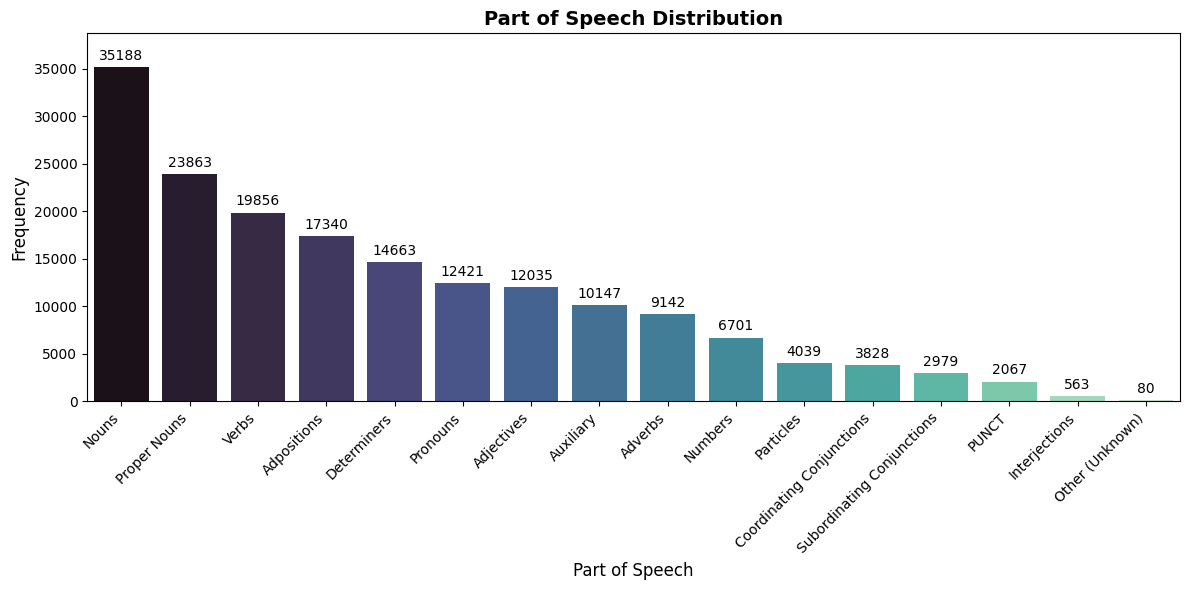

In [ ]:
pos_counts = Counter()
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space and token.pos_ != 'SYM':
            pos_counts[token.pos_] += 1

df_pos = pd.DataFrame(pos_counts.most_common(), columns=['POS_Tag', 'Frequency'])

total_valid_tokens = df_pos['Frequency'].sum()
df_pos['Percentage'] = (df_pos['Frequency'] / total_valid_tokens * 100).round(2).astype(str) + '%'

pos_mapping = {
    'NOUN': 'Nouns', 'VERB': 'Verbs', 'PROPN': 'Proper Nouns',
    'ADJ': 'Adjectives', 'ADV': 'Adverbs', 'ADP': 'Adpositions',
    'PRON': 'Pronouns', 'AUX': 'Auxiliary', 'DET': 'Determiners',
    'NUM': 'Numbers', 'PART': 'Particles', 'SCONJ': 'Subordinating Conjunctions',
    'CCONJ': 'Coordinating Conjunctions', 'INTJ': 'Interjections',
    'X': 'Other (Unknown)'
}
df_pos['Readable_Tag'] = df_pos['POS_Tag'].map(pos_mapping).fillna(df_pos['POS_Tag'])

print("--- POS Tag Distribution ---")
display(df_pos[['Readable_Tag', 'Frequency', 'Percentage']])

plt.close('all')
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_pos, x='Readable_Tag', y='Frequency',
                 palette='mako', hue='Readable_Tag', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8), textcoords='offset points',
                fontsize=10, color='black')

plt.ylim(0, df_pos['Frequency'].max() * 1.1)
plt.xlabel('Part of Speech', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Part of Speech Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The part-of-speech distribution is dominated by content-bearing categories:
**nouns (20.1%)**, **proper nouns (13.6%)**, and **verbs (11.3%)** together make up
nearly half of all tokens. The high share of proper nouns is expected for this
corpus, it reflects the dense naming of entities (NASA, Artemis, the Moon,
astronauts), consistent with the domain-specific vocabulary seen in the TF-IDF
analysis.

The substantial presence of **adjectives (6.9%)**, **adverbs (5.2%)**, and
**interjections (0.3%)** is relevant for a sentiment task: these are the categories
that most often carry evaluative and emotional content ("incredible", "fake",
"finally"). Their presence confirms the corpus contains the kind of subjective,
opinion-bearing language a sentiment classifier needs.

It is crucial to remember that this POS tagging is performed on the cleaned text, where emoji were
converted to words. As a result, a portion of
the nouns and verbs counted here originate from demojized emoji rather than typed
words. The distribution therefore reflects the corpus *as the models see it*, which
is the intended view, but the noun/verb counts should not be read as purely
natural-language usage.

### **2.4 Named Entity Recognition (NER) Analysis**

NER automatically identifies and categorizes real-world entities mentioned in
the text (people, organizations, locations, dates, and so on).

In [ ]:
entities = []
entity_labels = []
for doc in docs:
    for ent in doc.ents:
        entities.append(ent.text)
        entity_labels.append(ent.label_)

print(f"Total entities found: {len(entities)}")
print(f"Unique entities: {len(set(entities))}")

Total entities found: 18709
Unique entities: 4321


#### **2.4.1 Entity Type Distribution**

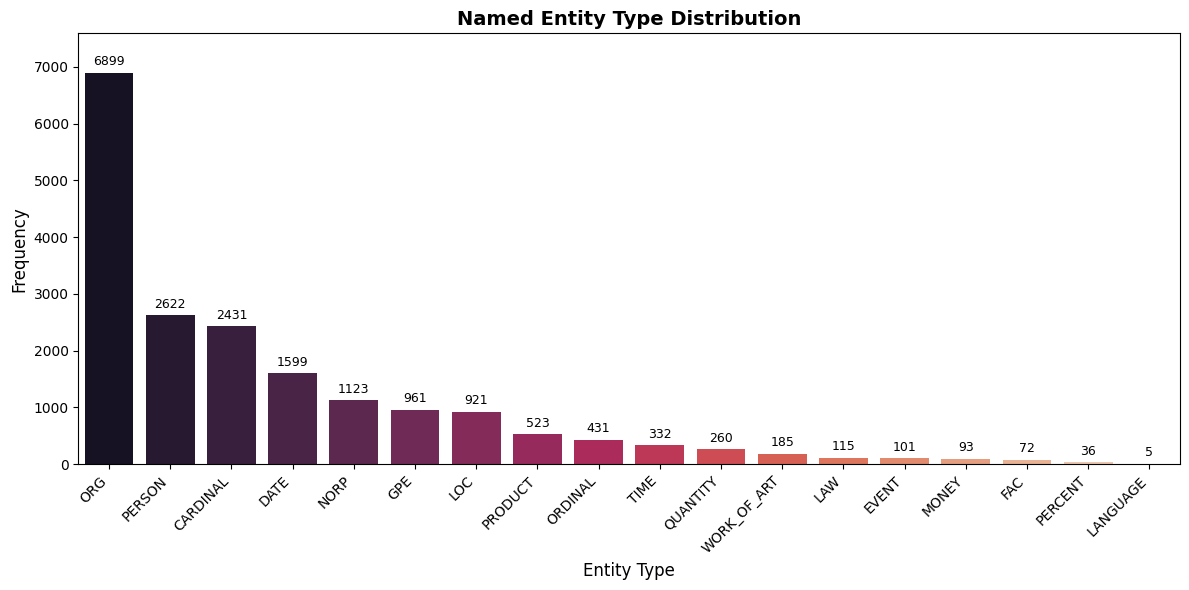

In [ ]:
label_freq = Counter(entity_labels)
label_df = pd.DataFrame(label_freq.most_common(), columns=['Entity Type', 'Count'])

plt.close('all')
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=label_df, x='Entity Type', y='Count',
                 palette='rocket', hue='Entity Type', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8), textcoords='offset points',
                fontsize=9, color='black')

plt.ylim(0, label_df['Count'].max() * 1.1)
plt.xlabel('Entity Type', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Named Entity Type Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Named Entity Recognition identifies **18,709 entity mentions** (4,321 unique). The
distribution is led by organizations (**ORG, 6,899**), overwhelmingly NASA and
related agencies, followed by persons (**PERSON, 2,622**), cardinal numbers
(**CARDINAL, 2,431**), and dates (**DATE, 1,599**). This profile matches the subject
matter: a space mission run by an organization, involving named individuals
(astronauts), with frequent references to figures (distances, costs, durations)
and time (launch dates, the Apollo era).

Smaller but meaningful categories include **NORP (1,123)**, nationalities/groups,
e.g. "American", and **GPE/LOC (961 / 921)**, geopolitical and physical places
(the United States, the Moon).

SpaCy's NER is trained on conventionally
formatted text, whereas our cleaned tweets are lowercased and stripped of
hashtags, mentions, and original casing. NER relies heavily on capitalization to
detect proper nouns, so on this normalized text its accuracy is reduced, therefore some
entities will be missed or mislabeled (for instance, "nasa" in lowercase is harder
to detect than "NASA"). The counts above should therefore be read as an
approximate, indicative profile of the entities discussed, not a precise extraction.

> **Top Entities for Main Categories**

Having seen *which types* of entities dominate, we now examine the specific
entities within the three largest categories, organizations, persons, and
cardinal numbers to see exactly what (and who) the discourse refers to.

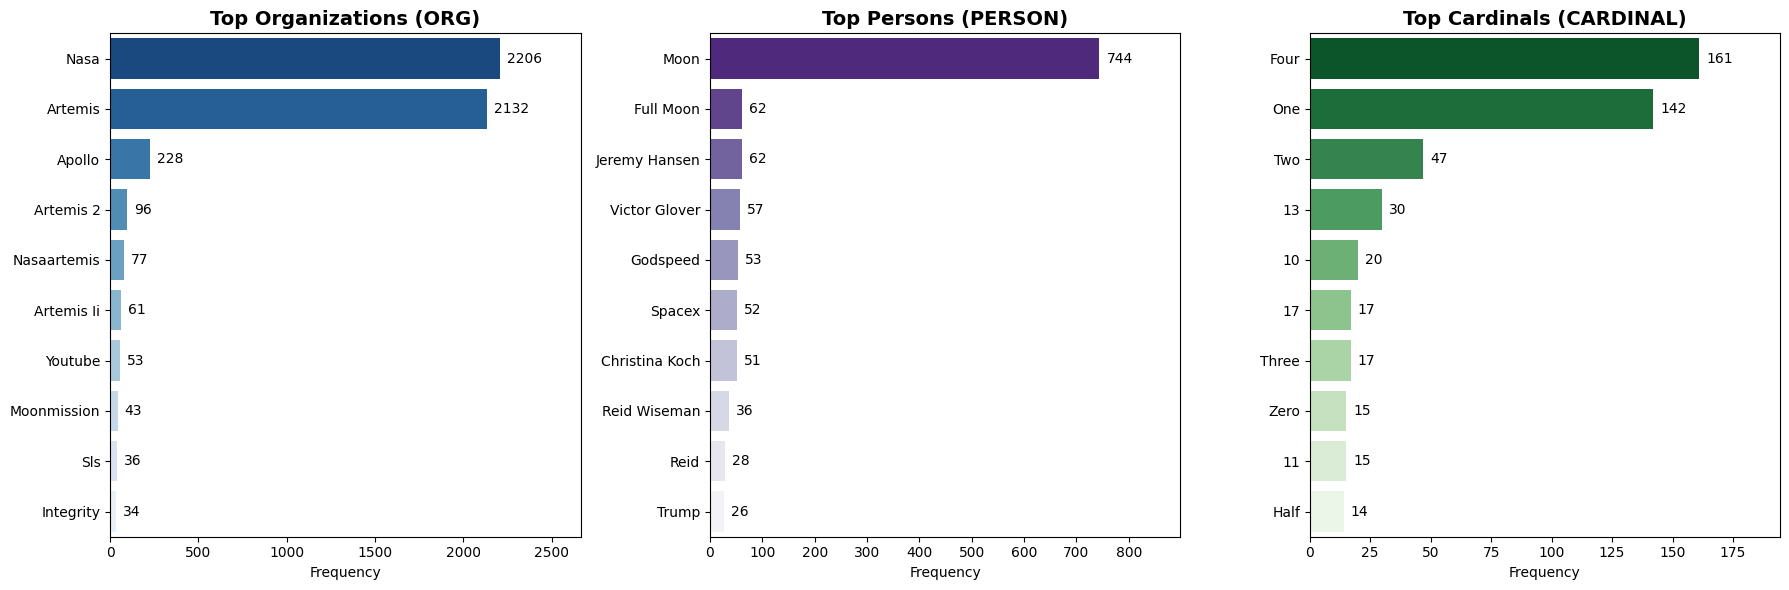

In [ ]:
target_labels = ['ORG', 'PERSON', 'CARDINAL']
entities_dict = {label: [] for label in target_labels}

for doc in docs:
    for ent in doc.ents:
        if ent.label_ in target_labels:
            clean_text = ent.text.strip().title()

            if len(clean_text) > 1:
                entities_dict[ent.label_].append(clean_text)

top_orgs = Counter(entities_dict['ORG']).most_common(10)
top_persons = Counter(entities_dict['PERSON']).most_common(10)
top_cards = Counter(entities_dict['CARDINAL']).most_common(10)

df_orgs = pd.DataFrame(top_orgs, columns=['Entity', 'Frequency'])
df_persons = pd.DataFrame(top_persons, columns=['Entity', 'Frequency'])
df_cards = pd.DataFrame(top_cards, columns=['Entity', 'Frequency'])

plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def annotate_hbars(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=10, color='black')
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

sns.barplot(data=df_orgs, y='Entity', x='Frequency', ax=axes[0], palette='Blues_r', hue='Entity', legend=False)
axes[0].set_title('Top Organizations (ORG)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('')
axes[0].set_xlabel('Frequency')
annotate_hbars(axes[0])

sns.barplot(data=df_persons, y='Entity', x='Frequency', ax=axes[1], palette='Purples_r', hue='Entity', legend=False)
axes[1].set_title('Top Persons (PERSON)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('')
axes[1].set_xlabel('Frequency')
annotate_hbars(axes[1])

sns.barplot(data=df_cards, y='Entity', x='Frequency', ax=axes[2], palette='Greens_r', hue='Entity', legend=False)
axes[2].set_title('Top Cardinals (CARDINAL)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('')
axes[2].set_xlabel('Frequency')
annotate_hbars(axes[2])

plt.tight_layout()
plt.show()

The NER analysis shows some interesting patterns, but also the limitations we
expected when using a pre-trained NER model on cleaned social media text.

- **Organizations (ORG).** Some of the top results ,*Nasaartemis*, *Artemis Ii*,
*Moonmission* are not real entities but tokenization errors: hashtags or
compound words that were not split correctly. They should be considered noise.
Among the correct detections, *SLS* (Space Launch System) is properly recognized,
which shows that the main organizations of the mission are captured despite the
noise.

- **Persons (PERSON).** This category contains the clearest errors. The top "person"
is *Moon*, and *Full Moon* also appears high in the ranking. This is a systematic
mistake, because spaCy tends to read the capitalized word "Moon" as a proper name.
It is the largest source of noise in this chart, and it makes the PERSON category
unreliable without additional filtering. However, the four real crew members,
*Jeremy Hansen*, *Victor Glover*, *Christina Koch*, *Reid Wiseman*, are all
correctly identified, which is a positive result. *Trump* also appears, probably
because of tweets about NASA funding with a political tone. Two other errors are
worth noting: *Godspeed* (a farewell message to the crew, wrongly read as a name)
and *SpaceX* (an organization classified as a person, likely in phrases such as
"thank you SpaceX"). Both are known errors of the `en_core_web_sm` model on
informal text.

- **Cardinals (CARDINAL).** This is the cleanest of the three categories. It is
dominated by *Four* and *One*, which match the references to the four crew members
and to the mission number ("Artemis 2 / II"). The number *13* probably refers to
Apollo 13 in tweets that compare the two missions.

In conclusion, this analysis shows both the usefulness and the limits of a
pre-trained NER model applied to cleaned, lowercase social media text. On one hand,
it correctly finds the main actors of the mission (the four astronauts, NASA, SLS);
on the other hand, it produces clear errors, especially classifying *Moon* as a
person. This confirms one of the design choices of the project: the classification
models do not use the extracted entities as features, but learn directly from the
text. In this way, these NER errors are not carried into the final task.

### **2.5 Sentence Analysis**



Beyond counting characters and words, we examine the sentence structure of the
tweets using spaCy's sentence boundary detection. Two metrics are of interest: how
long each sentence is (in tokens), and how many sentences each tweet contains. These
give a sense of the syntactic complexity of the text, whether the discourse is made
of short, single-statement posts or longer, multi-sentence messages.

--- Sentence Analysis Summary ---
Total sentences: 16090
Average sentence length: 12.1 tokens
Average sentences per document: 2.4


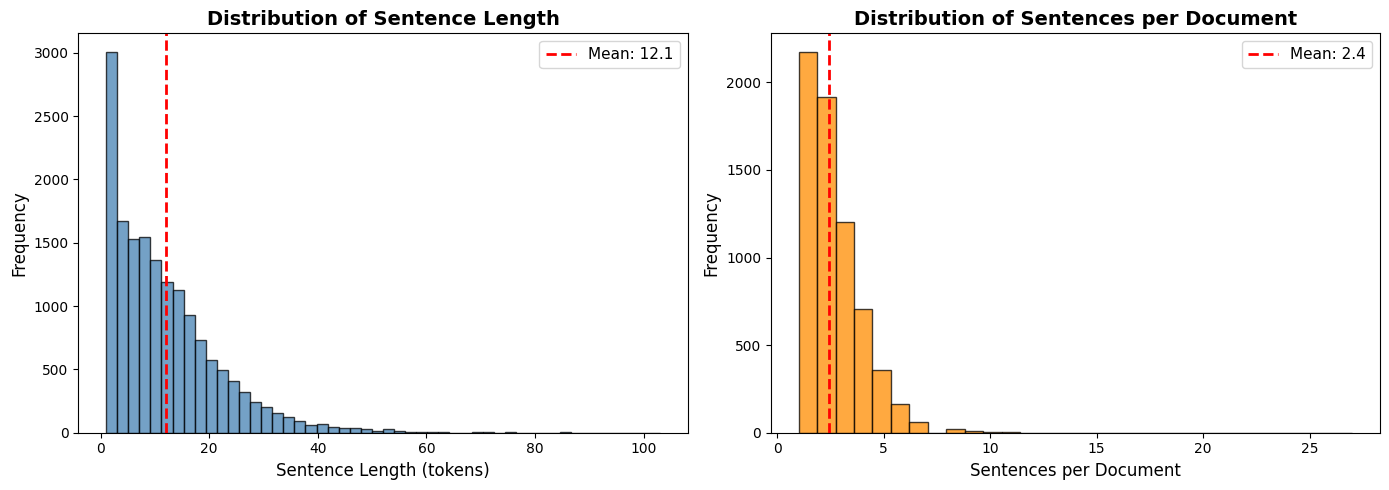

In [ ]:
sentence_lengths = []
sentences_per_doc = []

for doc in docs:
    doc_sentences = list(doc.sents)
    sentences_per_doc.append(len(doc_sentences))
    for sent in doc_sentences:
        sentence_lengths.append(len(sent))

print("--- Sentence Analysis Summary ---")
print(f"Total sentences: {len(sentence_lengths)}")
print(f"Average sentence length: {np.mean(sentence_lengths):.1f} tokens")
print(f"Average sentences per document: {np.mean(sentences_per_doc):.1f}")

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sentence_lengths, bins=50, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Sentence Length (tokens)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Sentence Length', fontsize=14, fontweight='bold')
mean_len = np.mean(sentence_lengths)
axes[0].axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
axes[0].legend(fontsize=11)

axes[1].hist(sentences_per_doc, bins=30, edgecolor='black', alpha=0.75, color='darkorange')
axes[1].set_xlabel('Sentences per Document', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Sentences per Document', fontsize=14, fontweight='bold')
mean_doc = np.mean(sentences_per_doc)
axes[1].axvline(mean_doc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_doc:.1f}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

The sentence-level analysis confirms the short, fragmented nature of the text. Across
the corpus, spaCy detected 16,090 sentences, with an average of 2.4 sentences per
tweet and an average sentence length of 12.1 tokens.

Both distributions are strongly right-skewed. Most tweets contain only one or two
sentences, with a small number of longer, multi-sentence posts forming the tail,
consistent with the long-form outliers seen in the earlier length analysis. Similarly,
most sentences are short (the mode is well below the 12.1-token mean), with the mean
pulled upward by a minority of longer sentences.

This structure is typical of social media: brief, self-contained messages rather than
extended prose. It also has a practical implication for modeling, because tweets are
short and contain few sentences, a moderate maximum sequence length is sufficient to
capture almost the entire content of each tweet during tokenization, with little risk
of losing information through truncation.

### **2.6 Dependency Parsing**

Dependency parsing maps the grammatical structure of each sentence by linking tokens
through typed syntactic relations (subject, object, modifier, and so on). For this
corpus it serves two exploratory purposes: first, to verify that the cleaned text
still retains enough syntactic structure to be parsed coherently (a sanity check on
the cleaning pipeline) and second, to characterize how information is structured in
the tweets (for example, through noun compounding versus subordinate clauses).

This analysis is descriptive: the dependency relations are not used as features by the
classification models, which learn directly from the text. The goal here is to
understand the corpus's syntactic profile, not to engineer features from it.

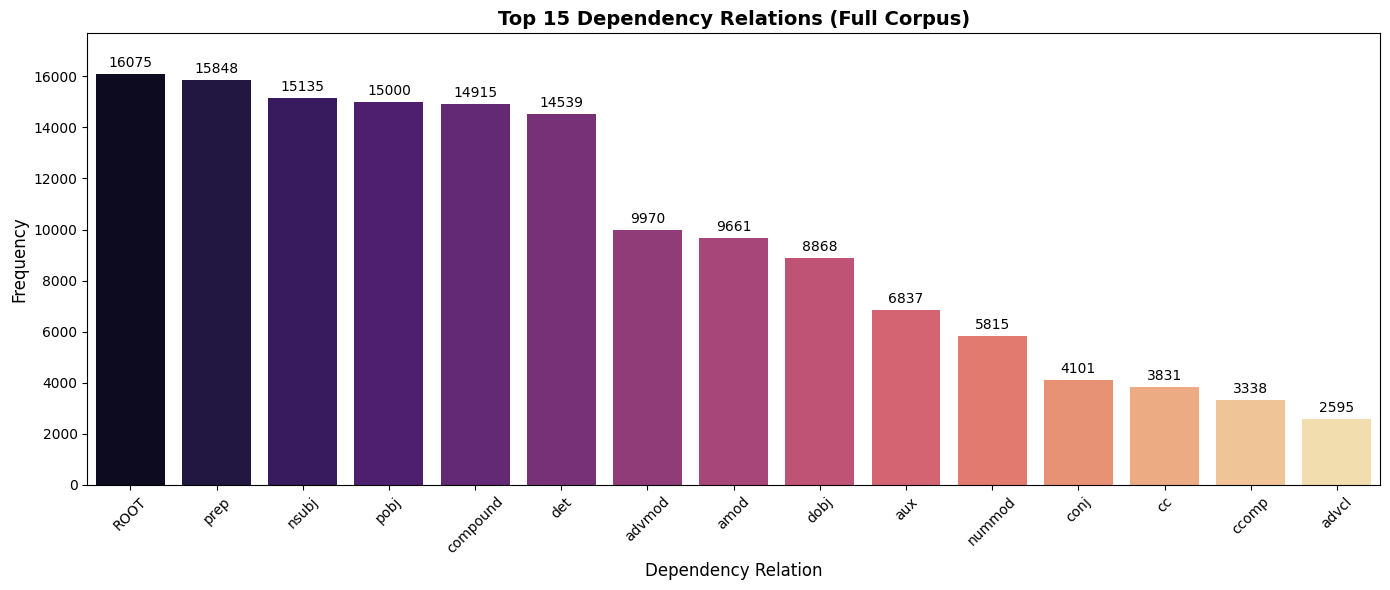

In [ ]:
dep_counts_all = Counter()
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            dep_counts_all[token.dep_] += 1

dep_counts_top = dep_counts_all.most_common(15)
df_dep_all = pd.DataFrame(dep_counts_top, columns=['Relation', 'Frequency'])

plt.close('all')
plt.figure(figsize=(14, 6))

ax = sns.barplot(data=df_dep_all, x='Relation', y='Frequency',
                 palette='magma', hue='Relation', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.title('Top 15 Dependency Relations (Full Corpus)', fontsize=14, fontweight='bold')
plt.xlabel('Dependency Relation', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, df_dep_all['Frequency'].max() * 1.1)
plt.tight_layout()
plt.show()

The dependency distribution reflects the compact but syntactically coherent nature of
the text. `ROOT` (16,075) tops the chart, which simply confirms that nearly every
detected sentence has a main predicate, an expected, almost trivial result, but a
useful sanity check that the cleaned text is still parseable.

More informative is the structure below it. The high and near-equal frequencies of
`prep` (15,848) and `pobj` (15,000): the two halves of prepositional phrases, together
with `nsubj` (15,135) and `compound` (14,915) indicate that these tweets convey
information mainly through nominal structures and prepositional attachment (e.g.
"crew of Artemis", "mission to the Moon") rather than through complex subordination.
This is consistent with the short average sentence length seen in the previous section.

Conversely, relations marking syntactic embedding such as `ccomp` (3,338, clausal
complements) and `advcl` (2,595, adverbial clauses), are comparatively rare. This
confirms that deeply nested, complex sentences are uncommon in the corpus: the text is
largely flat and declarative.

From a modeling perspective, this is reassuring rather than actionable. Because the
syntax is shallow and information is carried mostly at the lexical and phrasal level,
representations based on tokens and n-grams (as used by the models in this project)
capture most of the available signal, with relatively little lost by not modeling deep
syntactic structure explicitly.

## **3. Visual Summary**

### **3.1 Overall Word Cloud**

As a visual synthesis of the corpus vocabulary, we generate a word cloud from the
full set of lemmatized tokens (stopwords removed). Word size is proportional to
frequency, giving an immediate overview of the terms that dominate the discourse.
This complements the earlier TF-IDF analysis: where TF-IDF highlighted the most
*distinctive* terms, the word cloud reflects raw *frequency*.

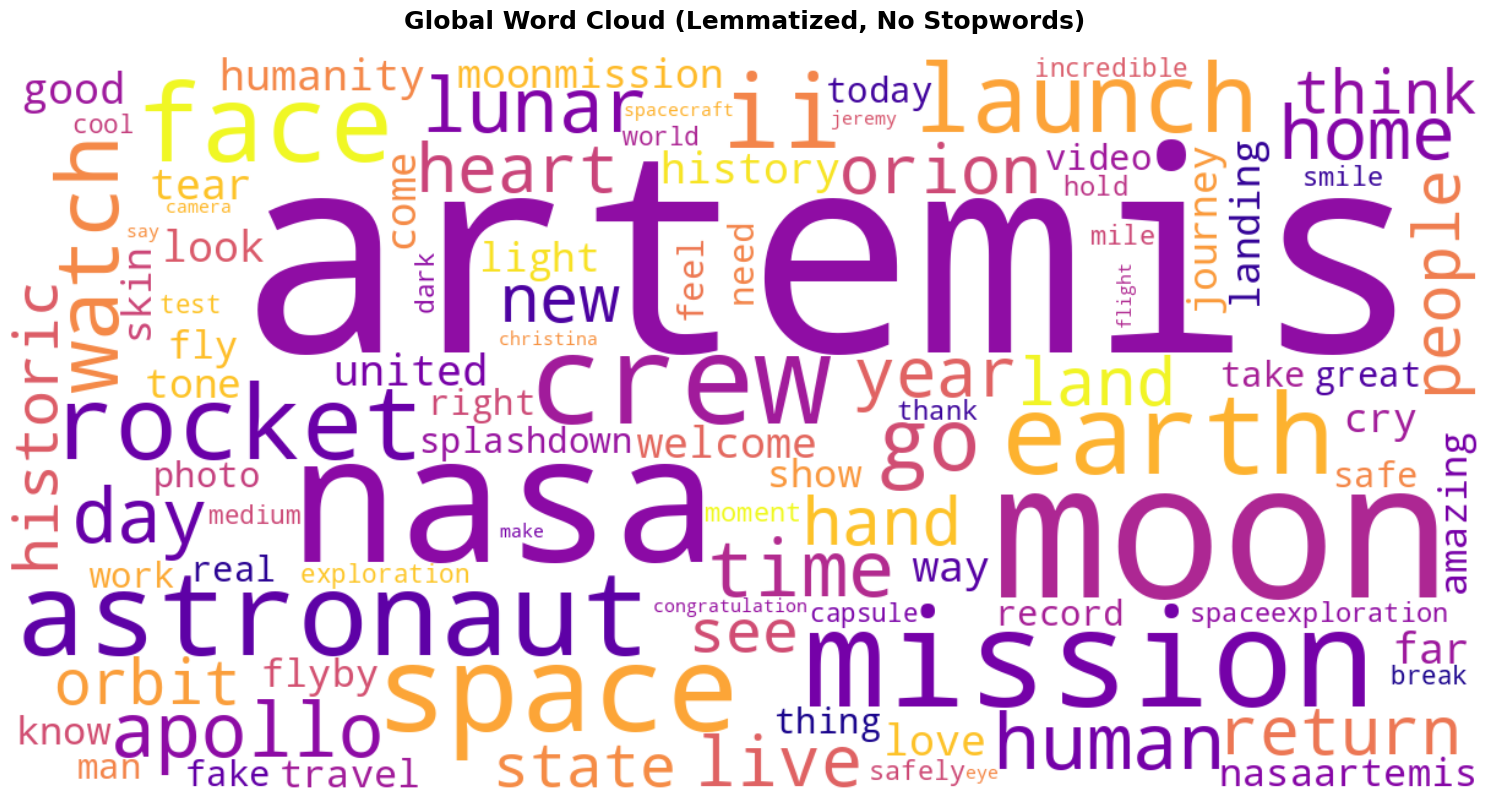

In [ ]:
plt.close('all')

text_for_wordcloud = ' '.join(all_lemmas)

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='plasma',
    max_words=100,
    collocations=False   # avoid auto-generated duplicate phrases
).generate(text_for_wordcloud)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Global Word Cloud (Lemmatized, No Stopwords)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

The global word cloud confirms the patterns identified throughout the analysis. The
largest terms (*artemis*, *nasa*, *moon*, *mission*) are the domain anchors that
appear across nearly all tweets, dominating the visualization as expected for a
mission-specific corpus.

Around these anchors, three groups of terms stand out:

- **Mission vocabulary** (*crew*, *astronaut*, *launch*, *rocket*, *orion*, *capsule*,
*orbit*, *lunar*, *spacecraft*): the concrete, factual language of the mission and its
hardware.
- **Event and temporal terms** (*launch*, *flyby*, *splashdown*, *return*, *landing*,
*welcome*, *home*): reflecting the key moments of the mission timeline.
- **Affective and emoji-derived terms** (*heart*, *face*, *cry*, *tear*, *smile*,
*love*, *amazing*, *incredible*, *historic*) the sentiment-bearing vocabulary. As noted
earlier, several of these (*face*, *cry*, *tear*, *heart*) originate from the
emoji-to-text conversion in `01_data_preparation`, which preserves emotional signal as text.

The cloud also surfaces a few tokenization artifacts already discussed: *ii*
(from "Artemis II"), *nasaartemis* and *moonmission* (unsplit hashtags) and a hint of
the skeptical strand of the discourse in terms like *fake* and *real*. Overall, the
visualization captures the corpus's dual character: a factual, domain-heavy core
surrounded by emotionally expressive, event-driven reactions.

### **3.2 Per-Category Word Cloud**

To see what distinguishes the four sentiment classes, we generate a separate word
cloud for each. Crucially, the shared domain anchors (*artemis*, *nasa*, *moon*,
*mission*, *space*) are excluded here: because they appear in every class, they would
otherwise dominate all four clouds and hide the vocabulary that is actually
*specific* to each sentiment. Removing them lets the distinguishing words surface.

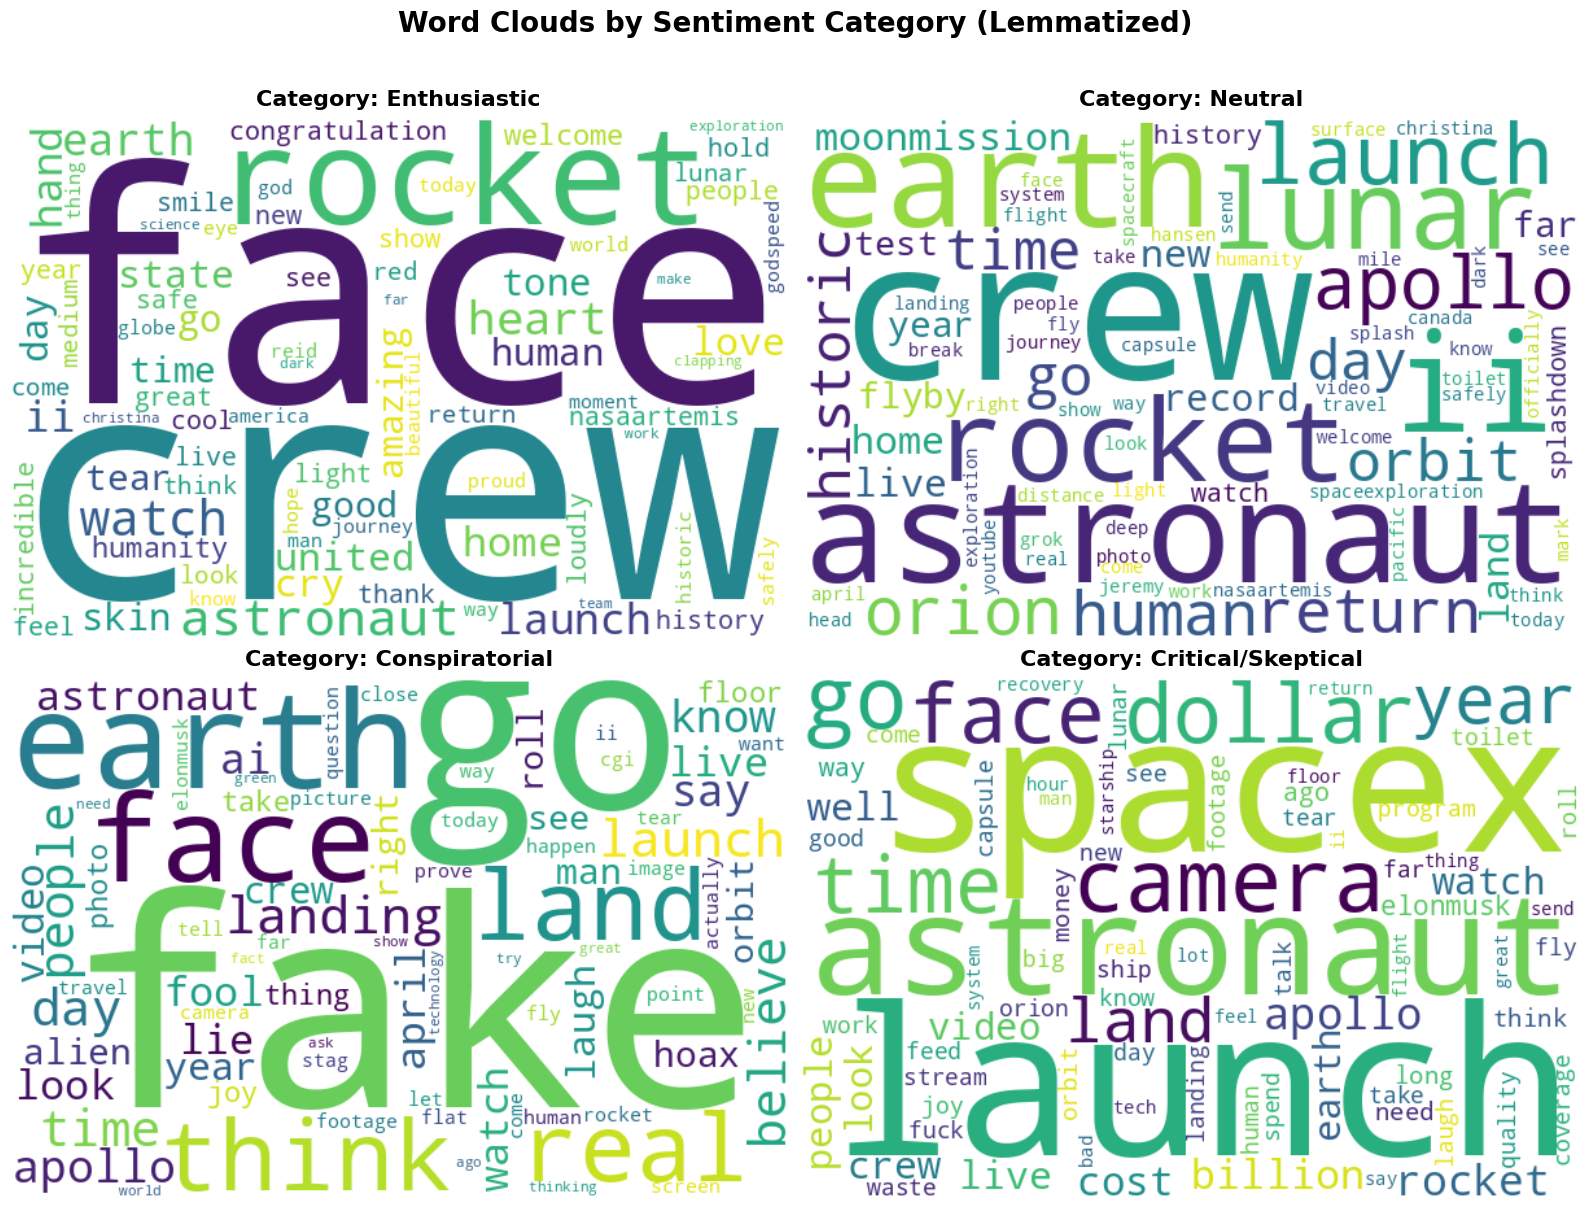

In [ ]:
plt.close('all')

# Domain terms excluded so they don't dominate every category's cloud
domain_stopwords = ['artemis', 'nasa', 'moon', 'mission', 'space']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sentiments = df[target_column].dropna().unique()

for ax, category_name in zip(axes.flat, sentiments):
    category_indices = df[df[target_column] == category_name].index.tolist()

    category_lemmas = []
    for i in category_indices:
        if i < len(docs):
            for token in docs[i]:
                if not token.is_punct and not token.is_space and not token.is_stop:
                    lemma = token.lemma_.lower().strip()
                    if lemma in custom_mapping:
                        lemma = custom_mapping[lemma]
                    if lemma != '-pron-' and len(lemma) > 1 and lemma not in domain_stopwords:
                        category_lemmas.append(lemma)

    if category_lemmas:
        wc = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap='viridis',
            max_words=80,
            collocations=False
        ).generate(' '.join(category_lemmas))
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Category: {category_name}', fontsize=16, fontweight='bold', pad=10)

    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment Category (Lemmatized)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

With the shared domain terms removed, each class reveals a distinct vocabulary
fingerprint and these mirror the per-class bigram patterns found in section 2.2.

* **Enthusiastic** is dominated by emoji-derived emotion words (*face*, *heart*, *cry*,
*tear*, *hand*, *smile*) together with celebratory and patriotic terms (*amazing*,
*incredible*, *love*, *proud*, *welcome*, *united*, *state*). This is the most
emotionally expressive cloud, confirming that enthusiasm in this corpus is conveyed
largely through emoji and strong evaluative language.

* **Neutral** is built from factual, descriptive vocabulary: *crew*, *launch*, *lunar*,
*earth*, *orbit*, *apollo*, *orion*, *return*, *splashdown*, *flyby*. There is almost no
affective content, consistent with informational, news-style reporting rather than
opinion.

* **Conspiratorial** is the most distinctive and unambiguous cloud. It is dominated by
denial and hoax vocabulary: *fake*, *land*, *think*, *believe*, *real*, *lie*, *hoax*,
*flat*, *alien*, *cgi*, *green screen*, *fool*. These terms directly question the
authenticity of the mission, a qualitatively different stance from ordinary criticism.

* **Critical/Skeptical** centers on cost, legitimacy, and media scrutiny: *launch*,
*spacex*, *dollar*, *billion*, *money*, *waste*, *cost*, *camera*, *stream*, *coverage*,
*quality*. The prominence of *spacex* and *dollar/billion/money* points to economic and
value-for-money critiques, while *camera*, *stream*, and *coverage* reflect thoughts of
how the events were broadcast, practical complaints rather than denial.

## **4. Conclusions & Takeaway**

To close the exploratory analysis, the table below consolidates the main descriptive
statistics produced throughout this notebook, dataset size, vocabulary, and the
linguistic features extracted with spaCy. The takeaways that follow summarize what
these findings mean for the modeling phase.

In [ ]:
target_column = 'Sentiment_label'

n_total = len(df)
sentiment_counts = df[target_column].dropna().value_counts()
top_sentiment = sentiment_counts.index[0]
top_sentiment_pct = (sentiment_counts.iloc[0] / n_total) * 100

summary = [
    ('Total Documents Processed',   f"{n_total:,}"),
    ('Sentiment Categories',        f"{len(sentiment_counts)}"),
    ('Most Frequent Sentiment',     f"{top_sentiment} ({top_sentiment_pct:.1f}%)"),
    ('Avg Words per Document',      f"{df['word_count'].mean():.1f}"),
    ('Total Tokens Extracted',      f"{len(all_tokens):,}"),
    ('Unique Tokens',               f"{len(set(all_tokens)):,}"),
    ('Unique Lemmas (Cleaned)',     f"{len(set(all_lemmas)):,}"),
    ('Vocabulary Reduction',        f"{(1 - len(set(all_lemmas))/len(set(all_tokens_no_stop)))*100:.1f}%"),
    ('Total Named Entities Found',  f"{len(entities):,}"),
    ('Unique Entity Types',         f"{len(set(entity_labels))}"),
    ('Total Sentences Processed',   f"{len(sentence_lengths):,}"),
    ('Avg Sentences per Document',  f"{np.mean(sentences_per_doc):.1f}"),
    ('Avg Tokens per Sentence',     f"{np.mean(sentence_lengths):.1f}"),
]

summary_df = pd.DataFrame(summary, columns=['Metric', 'Value'])

styled_summary = (summary_df.style
                  .set_caption("NLP Processing Summary")
                  .set_properties(**{'text-align': 'left', 'font-size': '14px', 'padding': '10px'})
                  .set_table_styles([
                      {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2C3E50'), ('margin-bottom', '15px')]},
                      {'selector': 'th', 'props': [('background-color', '#34495E'), ('color', 'white'), ('font-size', '15px'), ('text-align', 'left')]}
                  ])
                  .hide(axis='index'))

display(styled_summary)

Metric,Value
Total Documents Processed,"6,623"
Sentiment Categories,4
Most Frequent Sentiment,Enthusiastic (43.2%)
Avg Words per Document,25.8
Total Tokens Extracted,"174,920"
Unique Tokens,"12,256"
Unique Lemmas (Cleaned),"10,205"
Vocabulary Reduction,14.7%
Total Named Entities Found,"18,709"
Unique Entity Types,18


The analysis reveals several characteristics of the corpus that directly shape the
modeling strategy:

- **Strong class imbalance**: The two majority classes (Enthusiastic and Neutral)
  account for over 80% of the data, while the two minority classes
  (Critical/Skeptical and Conspiratorial) together make up less than 20%. This
  justifies two project-wide decisions: using **macro-averaged F1** as the evaluation
  metric (so all four classes count equally) and applying **class weighting** during
  training (so the minority classes are not ignored).

- **Short, fragmented text**: Tweets are brief with a median of about 22 words and 2.4
  sentences each (shallow syntactic structure). Token- and phrase-level
  representations therefore capture most of the available signal, and a moderate
  maximum sequence length is sufficient for the models, with little information lost
  to truncation.

- **Emotion expressed through emoji**: A large share of the sentiment-bearing
  vocabulary comes from emoji converted to text during preprocessing (*crying face*,
  *red heart*, and similar). Preserving emoji as text retains genuine emotional signal
  the models can use, particularly for the Enthusiastic class.

- **Distinct but overlapping minority classes.** The bigram and word-cloud analyses
  show that Conspiratorial and Critical/Skeptical tweets use different vocabularies,
  denial and hoax terms (*fake*, *hoax*, *cgi*) versus cost and legitimacy terms
  (*billion*, *waste*, *spacex*), yet share a common skeptical framing. This overlap
  anticipates a key result of the modeling phase: these two classes are the most
  frequently confused with one another.

Overall, the analysis describes a domain-focused, imbalanced, emotionally expressive
corpus of short texts. These properties motivate the modeling choices made in the
following notebooks and set realistic expectations for where classification is likely
to succeed (the well-separated majority classes) and where it is likely to struggle
(the overlapping minority classes).